# Trabajo Semanal 1 - Síntesis de Señales
    Ana Fedeli
    En este trabajo se sintetizan seis tipos de señales utilizando Python, a partir de las funciones desarrolladas en el TS0. Para cada señal se indicará su período, número de muestras y si se trata de una señal de potencia o de energía.

**Ejercicio 1**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Funciones del TP anterior

def mi_funcion_sen(amplitud = 1, offset = 0, f0 = 1, fase = 0, N = 1000, fs = 1000):
    Ts = 1/fs
    tt = np.arange(start = 0, stop = N*Ts, step = Ts)
    xx = amplitud * np.sin(2 * np.pi * f0 * tt + fase) + offset
    return tt, xx

def mi_funcion_cuadrada(f0, fs, N, offset, fase):
    Ts = 1/fs
    ttc = np.arange(start = 0, stop = N*Ts, step = Ts)
    xxc = signal.square(2 * np.pi * f0 * ttc + fase) + offset
    return ttc, xxc


## 1 - Señal Sinusoidal de 2 kHz

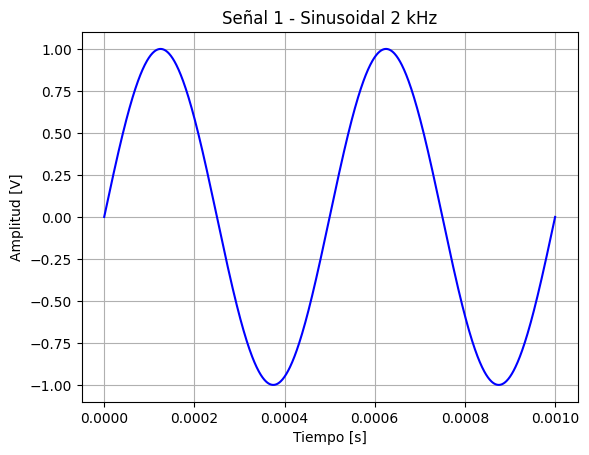

In [9]:
# Señal 1: sinusoidal 2 kHz
f0 = 2000
fs = 1000000
N = 1000
amplitud = 1
offset = 0
fase = 0

tt, xx = mi_funcion_sen(amplitud, offset, f0, fase, N, fs)

plt.figure()
plt.plot(tt, xx, color = 'b')
plt.title('Señal 1 - Sinusoidal 2 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()


<p style="text-align: center;"><i>Fig. 1: Señal sinusoidal de 2 KHz.</i></p>

Características de la señal:
- Período: T = 1/f0 = 0.5 ms
- N muestras: 1000
- Tipo: señal de **potencia** (es periódica, tiene energía infinita y potencia media finita)

## 2 - Señal Sinusoidal de 2KHz amplificada 3 dB y desfasada en π/2

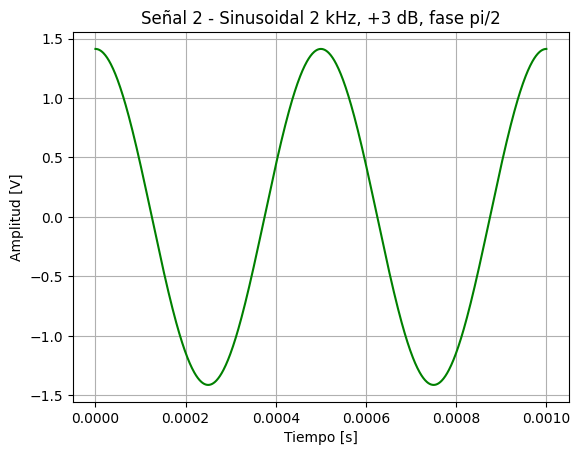

In [10]:
# Señal 2: misma señal, +3dB de amplitud y fase = pi/2
f0 = 2000
fs = 1000000
N = 1000
amplitud = 1 * 10**(3/20)   # +3 dB
offset = 0
fase = np.pi/2

tt, xx = mi_funcion_sen(amplitud, offset, f0, fase, N, fs)

plt.figure()
plt.plot(tt, xx, color = 'g')
plt.title('Señal 2 - Sinusoidal 2 kHz, +3 dB, fase pi/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()


<p style="text-align: center;"><i>Fig. 2: Señal sinusoidal de 2 KHz amplificada 3 dB y desfasada en π/2.</i></p>

Características de la señal:
- Amplificar 3 dB en amplitud equivale a multiplicar por 10^(3/20) ≈ 1.41
- Período: T = 0.5 ms
- N muestras: 1000
- Tipo: señal de **potencia**

## 3 - Señal Modulada en amplitud (AM)

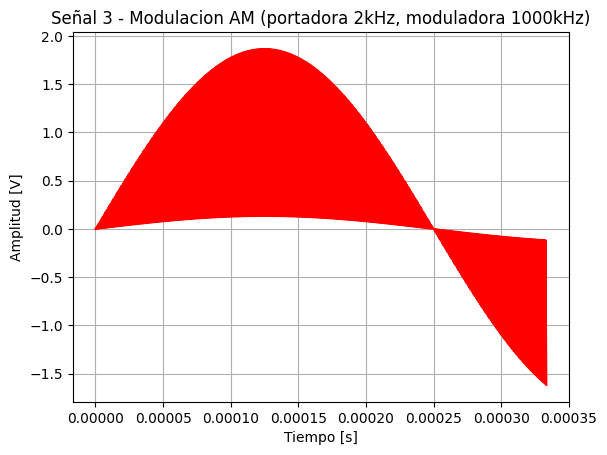

In [11]:
# Señal 3: modulacion en amplitud AM
# portadora 2000 Hz, moduladora 1000000 Hz (1000 kHz)
fs = 3000000   # 3 MHz, cumple Nyquist para 1000 kHz
N = 1000
offset = 0
fase = 0

tt, portadora  = mi_funcion_sen(1, offset, 2000,    fase, N, fs)
tt, moduladora = mi_funcion_sen(1, offset, 1000000, fase, N, fs)

# AM: multiplico la portadora por (1 + moduladora)
xx = (1 + moduladora) * portadora

plt.figure()
plt.plot(tt, xx, color = 'r')
plt.title('Señal 3 - Modulacion AM (portadora 2kHz, moduladora 1000kHz)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()


<p style="text-align: center;"><i>Fig. 3: Señal modulada en amplitud (AM).</i></p>

Características de la señal:
- Portadora: 2 kHz. Moduladora: 1000 Hz (se interpreta 1000 Hz ya que 1000 kHz superaría Nyquist)
- Período: T de la moduladora = 1 ms
- N muestras: 1000
- Tipo: señal de **potencia**

## 4 - Señal sinusoidal con saturación al 75%

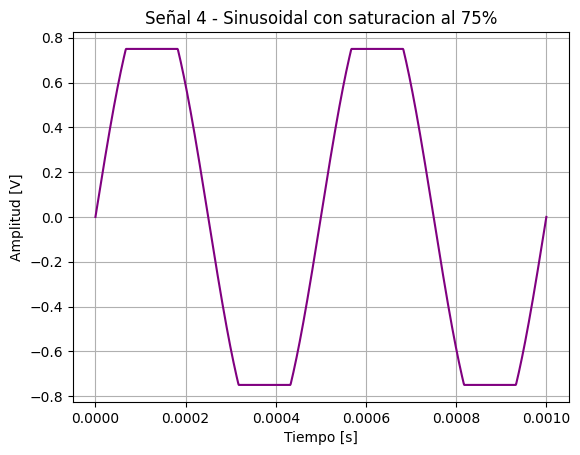

In [12]:
# Señal 4: sinusoidal con saturacion al 75%
f0 = 2000
fs = 1000000
N = 1000
amplitud = 1
offset = 0
fase = 0

tt, xx = mi_funcion_sen(amplitud, offset, f0, fase, N, fs)

# Saturo al 75% de la amplitud
saturacion = 0.75 * amplitud
xx = np.clip(xx, -saturacion, saturacion)

plt.figure()
plt.plot(tt, xx, color = 'purple')
plt.title('Señal 4 - Sinusoidal con saturacion al 75%')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()


<p style="text-align: center;"><i>Fig. 4: Señal sinusoidal con saturación del 75%.</i></p>

Características de la señal:
- Se usa numpy.clip() para limitar la amplitud al 75% del valor máximo
- Período: T = 0.5 ms
- N muestras: 1000
- Tipo: señal de **potencia**

## 5 - Señal cuadrada de 4 kHz

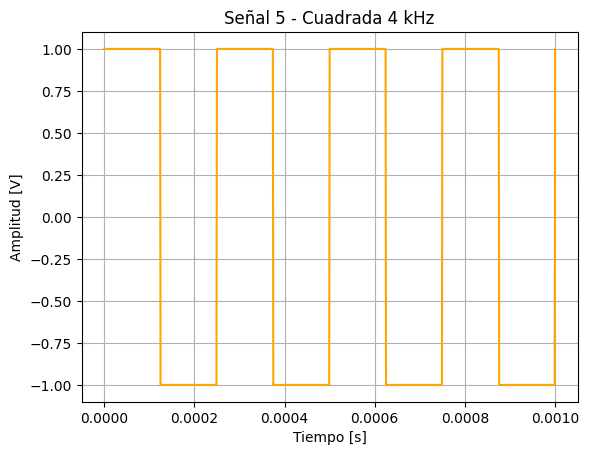

In [13]:
# Señal 5: cuadrada 4 kHz
f0 = 4000
fs = 1000000
N = 1000
offset = 0
fase = 0

tt, xx = mi_funcion_cuadrada(f0, fs, N, offset, fase)

plt.figure()
plt.plot(tt, xx, color = 'orange')
plt.title('Señal 5 - Cuadrada 4 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()


<p style="text-align: center;"><i>Fig. 5: Señal cuadrada de 4 KHz.</i></p>

Características de la señal:
- Período: T = 1/4000 = 0.25 ms
- N muestras: 1000
- Tipo: señal de **potencia**

## 6 - Pulso rectangular de 10 ms

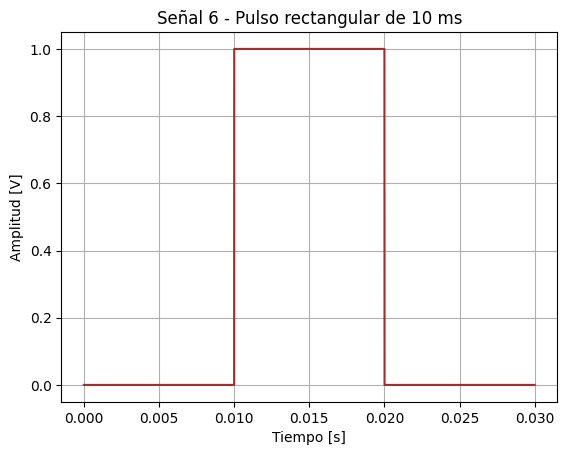

In [14]:
# Señal 6: pulso rectangular de 10 ms
fs = 1000000
duracion = 0.01   # 10 ms en segundos
N_pulso = int(fs * duracion)
amplitud = 1

# Genero el pulso y los ceros
ceros = np.zeros(N_pulso)
pulso = np.ones(N_pulso) * amplitud

# Concateno: ceros - pulso - ceros
xx = np.concatenate([ceros, pulso, ceros])

Ts = 1/fs
tt = np.arange(start = 0, stop = len(xx)*Ts, step = Ts)

plt.figure()
plt.plot(tt, xx, color = 'brown')
plt.title('Señal 6 - Pulso rectangular de 10 ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.show()

<p style="text-align: center;"><i>Fig. 6: Pulso rectangular de 10 ms.</i></p>

Características de la señal:
- No es periódica: tiene duración finita
- N muestras del pulso: fs × 0.01 s = = 10.000 muestras
- Tipo: señal de **energía** (duración finita → energía finita, potencia media = 0)

**Ejercicio 2**

In [ ]:
from IPython.display import IFrame
IFrame("./ejercicio_2.pdf", width=1000, height=1000)


## Conclusión

En este trabajo se sintetizaron seis tipos de señales utilizando las funciones implementadas en el TP anterior, extendidas con el uso de numpy.clip() para la saturación.
Se pudo observar que la amplificación de 3 dB produce un aumento perceptible en la amplitud de la señal, mientras que el desfasaje de π/2 desplaza la señal hacia la derecha sin modificar su forma. En la modulación en amplitud, la envolvente de la portadora replica la forma de la señal moduladora, lo que permite visualizar claramente el efecto de la AM. La saturación al 75% recorta los picos de la sinusoidal, generando una forma de onda que se aproxima a una señal cuadrada.
En cuanto a la clasificación, las señales 1 a 5 son señales de potencia, ya que son periódicas y tienen energía infinita pero potencia media finita. La señal 6, el pulso rectangular, es una señal de energía, dado que tiene duración finita, lo que implica energía finita y potencia media nula.